[[0.19245009+0.j         0.38490018-0.19245009j]
 [0.38490018+0.19245009j 0.76980036+0.j        ]]

[[0.6401844 +0.j]
 [0.76822128+0.j]]

1


C:\Users\Aayush\AppData\Local\Temp\ipykernel_11464\2640136552.py:59: DeprecationWarning: The class ``qiskit.circuit.library.phase_estimation.PhaseEstimation`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use qiskit.circuit.library.phase_estimation instead.
  return PhaseEstimation(n, U_h)
C:\Users\Aayush\AppData\Local\Temp\ipykernel_11464\2640136552.py:71: DeprecationWarning: The class ``qiskit.circuit.library.arithmetic.exact_reciprocal.ExactReciprocal`` is deprecated as of Qiskit 2.2. It will be removed in Qiskit 3.0. Use the class qiskit.circuit.library.ExactReciprocalGate instead.
  reciprocal = ExactReciprocal(


measurement counts: {'010': 3059, '000': 1014, '101': 10, '100': 1, '001': 9, '110': 2, '011': 1}


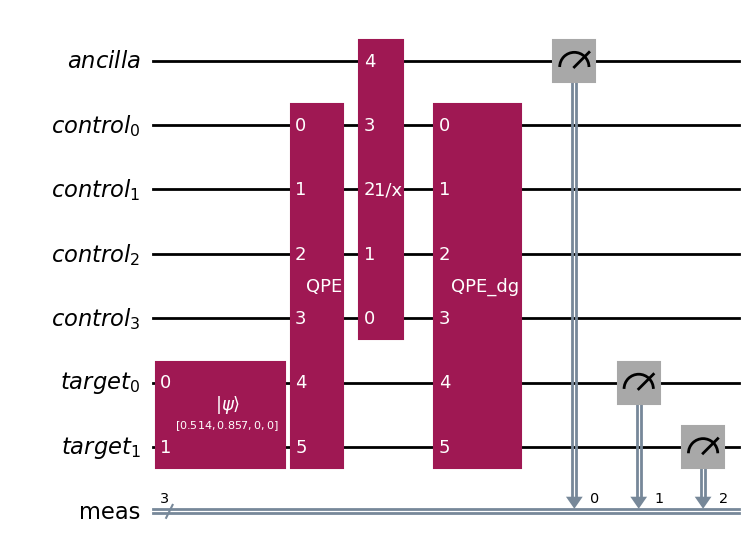

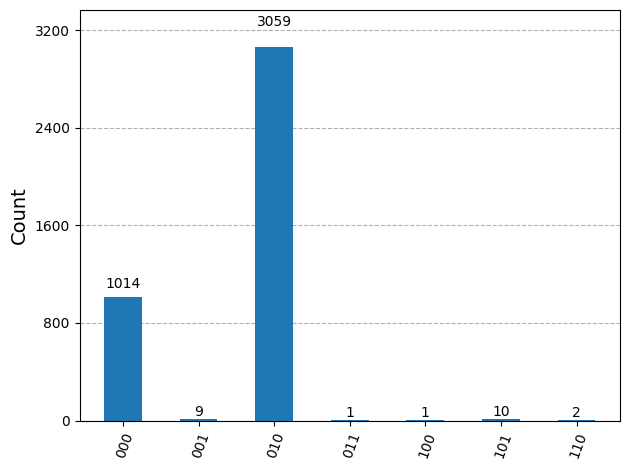

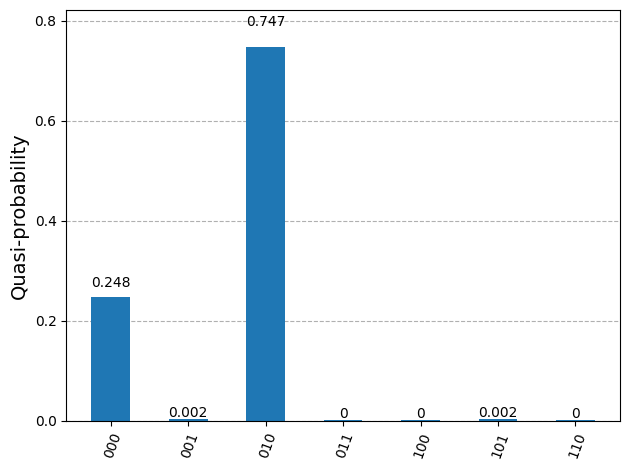

C:\Users\Aayush\AppData\Local\Temp\ipykernel_11464\2640136552.py:59: DeprecationWarning: The class ``qiskit.circuit.library.phase_estimation.PhaseEstimation`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use qiskit.circuit.library.phase_estimation instead.
  return PhaseEstimation(n, U_h)
C:\Users\Aayush\AppData\Local\Temp\ipykernel_11464\2640136552.py:71: DeprecationWarning: The class ``qiskit.circuit.library.arithmetic.exact_reciprocal.ExactReciprocal`` is deprecated as of Qiskit 2.2. It will be removed in Qiskit 3.0. Use the class qiskit.circuit.library.ExactReciprocalGate instead.
  reciprocal = ExactReciprocal(


{'110': 73, '011': 78, '100': 49, '101': 55, '001': 48, '000': 85, '010': 65, '111': 16}
{'110': np.float64(0.3945254362261378), '011': np.float64(0.40781282549676984), '100': np.float64(0.3232299675777271), '101': np.float64(0.3424482280762743), '001': np.float64(0.3199147007848367), '000': np.float64(0.4257190080017419), '010': np.float64(0.37228047294083133), '111': np.float64(0.18470283861584405)}
measurement counts: {'0000': 895, '1000': 905, '1101': 73, '0100': 870, '1100': 940, '0111': 78, '1001': 49, '1011': 55, '0011': 48, '0001': 85, '0101': 65, '1010': 7, '1111': 16, '0010': 5, '0110': 5}


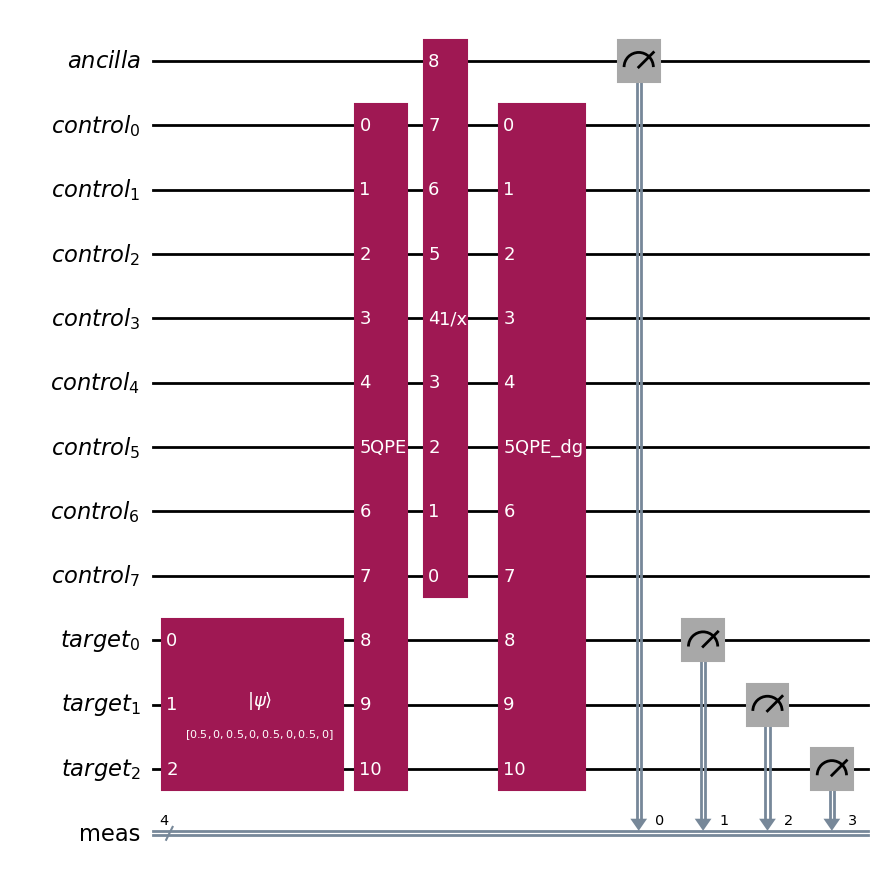

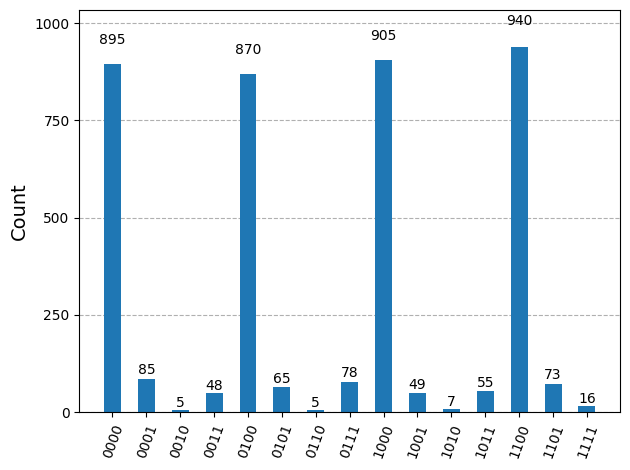

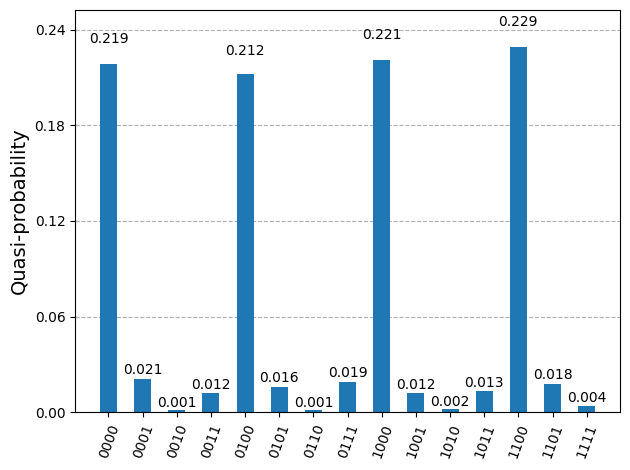

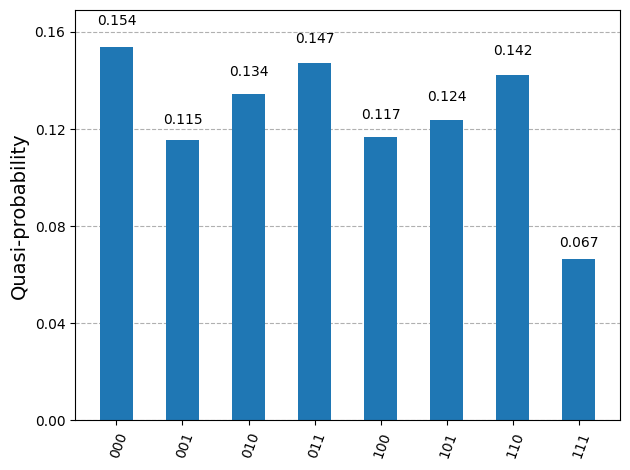

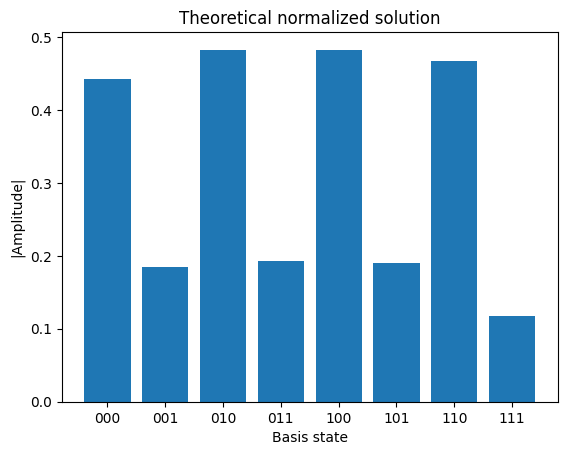

Fidelity = 0.869377203261679


In [1]:
import numpy as np

def make_hermitian(A, b):
    b = np.asarray(b).reshape(-1,1)
    if np.allclose(A, A.conj().T):
        return A/np.linalg.norm(A), b/np.linalg.norm(b)

    n = A.shape[0]

    A_h = np.block([
        [np.zeros((n, n), dtype=complex), A],
        [A.conj().T, np.zeros((n, n), dtype=complex)]
    ])

    b_h = np.vstack([
        b,
        np.zeros((n, 1), dtype=complex)
    ])

    return A_h/np.linalg.norm(A_h), b_h/np.linalg.norm(b_h)
import scipy.linalg as la
import numpy as np
A = np.array([
    [1, 2-1j],
    [2+1j, 4]
], dtype=complex)

b = np.array([
    [5],
    [6]
], dtype=complex)

A_h, b_h = make_hermitian(A, b)
print(A_h)
print()
print(b_h)
print()
num_qubits = int(np.log2(len(b_h)))
print(num_qubits)

from qiskit import *
from qiskit.quantum_info import Operator
from qiskit.circuit.library import UnitaryGate , QFT
from qiskit.circuit.library.arithmetic import ExactReciprocal
from qiskit.circuit.library import PhaseEstimation
import numpy as np
A_h, b_h = make_hermitian(A, b)

def make_U(A_h):
    evals ,evecs = np.linalg.eigh(A_h)
    t= 2*np.pi/max(evals)
    return la.expm(1j * A_h * t)
evals ,evecs = np.linalg.eigh(A_h)
U = make_U(A_h)
U_h = UnitaryGate(U)
C = min(abs(evals))
def QPE(U_h = U_h, m=1):
    n = m*len(np.asarray(b_h).flatten())
    return PhaseEstimation(n, U_h)
def HHL(A_h, b_h, U_h, m=1):
    n = m*len(np.asarray(b_h).flatten())
    ancilla = QuantumRegister(1, name= 'ancilla')
    control = QuantumRegister(n, name= 'control')
    target = QuantumRegister(int(np.log2(len(b_h))), name= 'target')
    c_reg = ClassicalRegister(int(np.log2(len(b_h)))+1, name = 'meas')
    qc = QuantumCircuit(ancilla, control, target, c_reg)
    qpe=QPE(U_h = U_h,m=m)
    d =  np.min(np.abs(np.linalg.eigvals(A_h)))
    # amplitude encoding in target
    b_h = np.asarray(b_h).flatten()
    reciprocal = ExactReciprocal(
        num_state_qubits= n,
        scaling= d
    )

    qc.initialize(b_h, target) 
    # apply QPE
    qc.append(qpe, list(control) + list(target))
    # apply control rotation
    qc.append(reciprocal, list(control[::-1] + [ancilla[0]]) )
    # apply IQPE
    qc.append(qpe.inverse(), list(control) + list(target))
    qc.measure(ancilla[0],c_reg[0])
    
    qc.measure(target, c_reg[1:])
    return qc
A = np.array([
    [1,2],
    [3,4]
], dtype=complex)

b = np.array([3,5], dtype=float)

A_h, b_h = make_hermitian(A, b)


U = make_U(A_h)
U_h = UnitaryGate(U)


qc = HHL(A_h, b_h, U_h)
%matplotlib inline
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram, plot_distribution
import matplotlib.pyplot as plt

sim = AerSimulator()
circuit = transpile(qc, sim)
job = sim.run(circuit, shots =4096)
result = job.result()
counts = result.get_counts()
total_shots = sum(counts.values())
probabilities = {state: count / total_shots for state, count in counts.items()}
plot_distribution = (counts)

qc.draw('mpl')
print("measurement counts:", counts)
plot_histogram(counts)
plot_distribution = (counts)
plot_histogram(probabilities)
plt.show()


A = np.array([
[5,1,0,0,0,0,0,0],
[1,5,1,0,0,0,0,0],
[0,1,5,1,0,0,0,0],
[0,0,1,5,1,0,0,0],
[0,0,0,1,5,1,0,0],
[0,0,0,0,1,5,1,0],
[0,0,0,0,0,1,5,1],
[0,0,0,0,0,0,1,4]
], dtype=complex)

b = np.array([1,0,1,0,1,0,1,0], dtype=complex)
A_h, b_h = make_hermitian(A, b)

U = make_U(A_h)
U_h = UnitaryGate(U)

qc = HHL(A_h, b_h, U_h=U_h, m = 1)
sim = AerSimulator()
circuit = transpile(qc, sim)
job = sim.run(circuit, shots =4096)
result = job.result()
counts = result.get_counts()
total_shots = sum(counts.values())
probabilities = {state: count / total_shots for state, count in counts.items()}
plot_distribution = (counts)
success_counts = {}

for bitstring, count in counts.items():

    if bitstring[-1] == '1':   # ancilla = 1

        target_state = bitstring[:-1]

        success_counts[target_state] = (
            success_counts.get(target_state, 0)
            + count
        )
print(success_counts)
total_success = sum(success_counts.values())

amps = {}

for state, count in success_counts.items():
    amps[state] = np.sqrt(count / total_success)

print(amps)

qc.draw('mpl')
print("measurement counts:", counts)
plot_histogram(counts)
plot_distribution = (counts)
plot_histogram(probabilities)
plot_histogram(amps)
plt.show()
x = np.linalg.solve(A_h, b_h).flatten()
x = x / np.linalg.norm(x)

theoretical_abs = np.abs(x)

states = [format(i, f'0{int(np.log2(len(x)))}b')
          for i in range(len(x))]

plt.bar(states, theoretical_abs)
plt.xlabel("Basis state")
plt.ylabel("|Amplitude|")
plt.title("Theoretical normalized solution")
plt.show()
hhl_vec = np.array([
    amps.get(format(i,'03b'),0)
    for i in range(8)
])

hhl_vec = hhl_vec/np.linalg.norm(hhl_vec)

fidelity = abs(np.vdot(theoretical_abs, hhl_vec))**2

print("Fidelity =", fidelity)